In [9]:
import time
import importlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tabular_pipeline as tabular_pipeline_module
importlib.reload(tabular_pipeline_module)
from tabular_pipeline import tabular_pipeline

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

Libraries installed successfully..



[PIPELINE] Starting Tabular Data Processing Pipeline...


[ROUTE] Successfully sent to Tabular EDA.


-> Processing data file: 'test.csv'



The shape of the dataset: (20000, 23)
  Customer ID              Name Gender  Age  Income (USD) Income Stability  \
0     C-26247  Tandra Olszewski      F   47       3472.69              Low   
1     C-35067     Jeannette Cha      F   57       1184.84              Low   
2     C-34590      Keva Godfrey      F   52       1266.27              Low   
3     C-16668      Elva Sackett      M   65       1369.72             High   
4     C-12196    Sade Constable      F   60       1939.23             High   

             Profession Type of Employment    Location  \
0  Commercial associate           Managers  Semi-Urban   
1               Working        Sales staff       Rural   
2               Working                NaN  Semi-Urban   
3             Pensioner                NaN       Rural   
4             Pensioner                NaN       Urban   

  

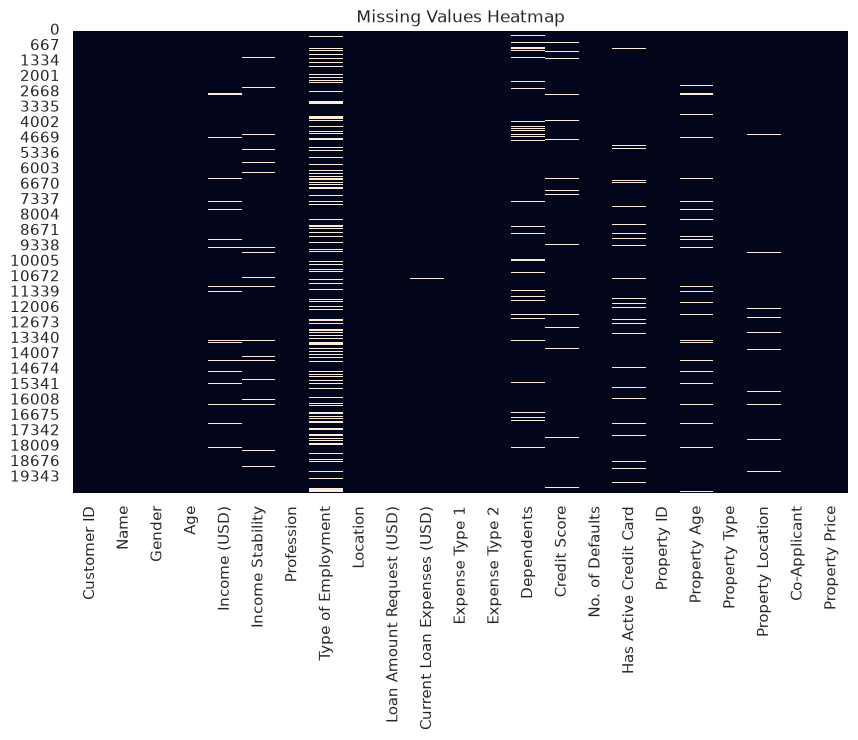



Central Tendency: 

Column: 'Age'
  -> Mean:   39.94
  -> Median: 40.00
  -> Mode:   18
  -> skew:   0.055204109456211466
  -> Kurtosis:   -1.3869507430478585
count    20000.000000
mean        39.940500
std         16.097618
min         18.000000
25%         25.000000
50%         40.000000
75%         55.000000
max         65.000000
Name: Age, dtype: float64

Column: 'Income (USD)'
  -> Mean:   2537.00
  -> Median: 2224.59
  -> Mode:   1301.27
  -> skew:   3.409820495291463
  -> Kurtosis:   31.0521164378907
count    19250.000000
mean      2536.995394
std       1415.908803
min        368.590000
25%       1659.722500
50%       2224.590000
75%       3082.925000
max      30427.680000
Name: Income (USD), dtype: float64

Column: 'Loan Amount Request (USD)'
  -> Mean:   88859.08
  -> Median: 74565.99
  -> Mode:   21137.19
  -> skew:   1.2777280089940513
  -> Kurtosis:   1.970848862932483
count     20000.000000
mean      88859.076706
std       60007.333673
min        6185.480000
25%       40

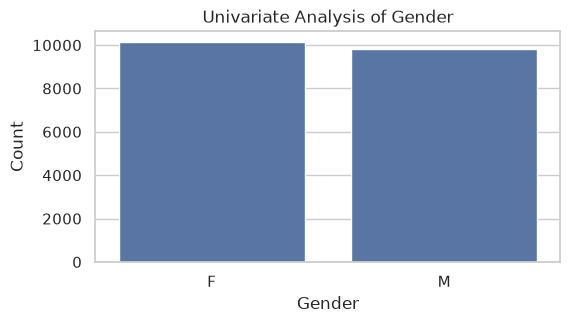


--- Analysis for Income Stability ---
Frequency Counts:
Income Stability
Low     17501
High     1686
Name: count, dtype: int64
Percentages:
Income Stability
Low     91.2128
High     8.7872
Name: proportion, dtype: float64


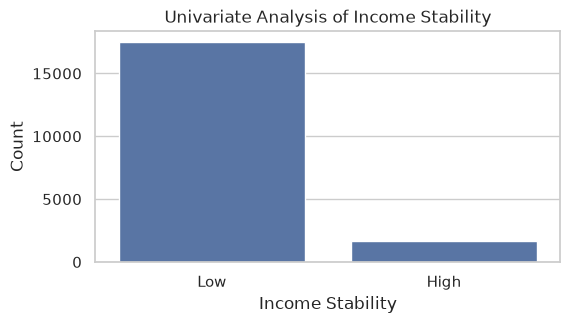


--- Analysis for Profession ---
Frequency Counts:
Profession
Working                 11405
Commercial associate     5247
Pensioner                1764
State servant            1577
Student                     4
Unemployed                  2
Maternity leave             1
Name: count, dtype: int64
Percentages:
Profession
Working                 57.025
Commercial associate    26.235
Pensioner                8.820
State servant            7.885
Student                  0.020
Unemployed               0.010
Maternity leave          0.005
Name: proportion, dtype: float64


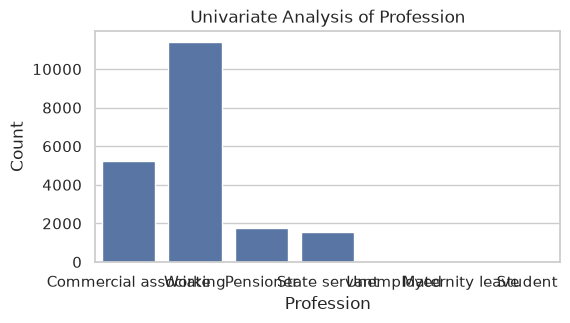


--- Analysis for Location ---
Frequency Counts:
Location
Semi-Urban    14463
Rural          3436
Urban          2101
Name: count, dtype: int64
Percentages:
Location
Semi-Urban    72.315
Rural         17.180
Urban         10.505
Name: proportion, dtype: float64


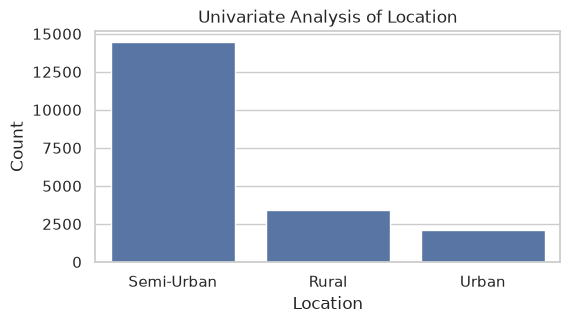


--- Analysis for Expense Type 1 ---
Frequency Counts:
Expense Type 1
N    12816
Y     7184
Name: count, dtype: int64
Percentages:
Expense Type 1
N    64.08
Y    35.92
Name: proportion, dtype: float64


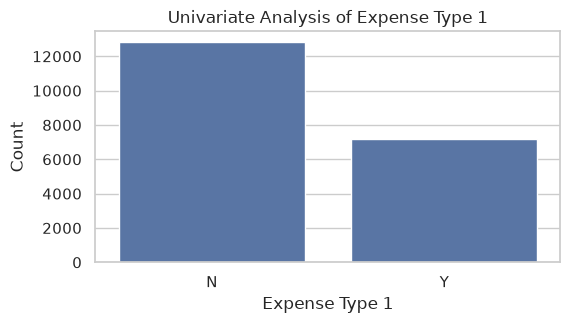


--- Analysis for Expense Type 2 ---
Frequency Counts:
Expense Type 2
Y    13383
N     6617
Name: count, dtype: int64
Percentages:
Expense Type 2
Y    66.915
N    33.085
Name: proportion, dtype: float64


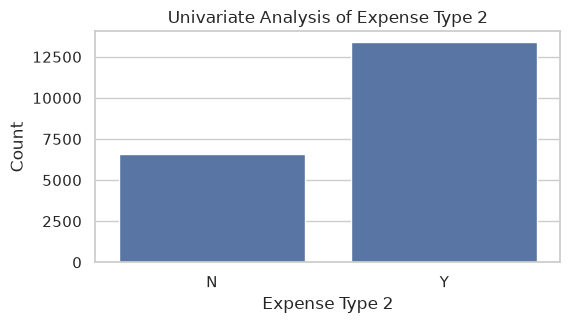


--- Analysis for Has Active Credit Card ---
Frequency Counts:
Has Active Credit Card
Active         6418
Inactive       6376
Unpossessed    6130
Name: count, dtype: int64
Percentages:
Has Active Credit Card
Active         33.914606
Inactive       33.692665
Unpossessed    32.392729
Name: proportion, dtype: float64


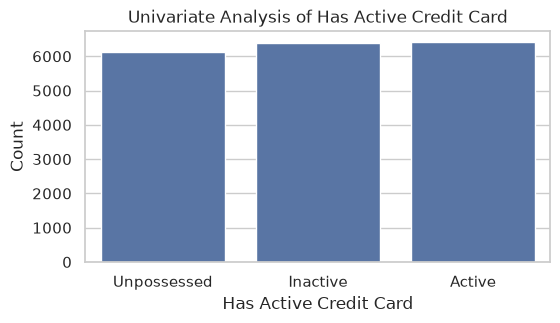


--- Analysis for Property Location ---
Frequency Counts:
Property Location
Semi-Urban    6839
Rural         6768
Urban         6233
Name: count, dtype: int64
Percentages:
Property Location
Semi-Urban    34.470766
Rural         34.112903
Urban         31.416331
Name: proportion, dtype: float64


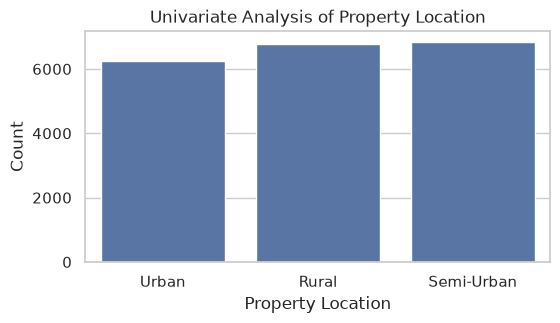


--- Analysis for Co-Applicant ---
Frequency Counts:
Co-Applicant
1    17004
0     2919
?       77
Name: count, dtype: int64
Percentages:
Co-Applicant
1    85.020
0    14.595
?     0.385
Name: proportion, dtype: float64


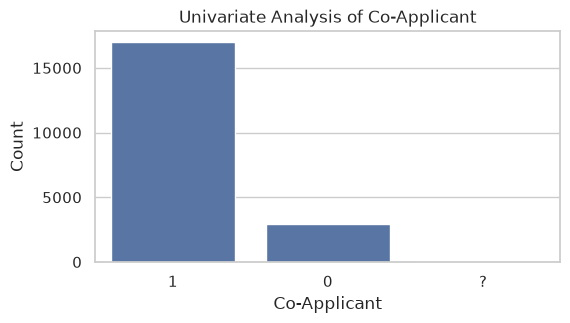

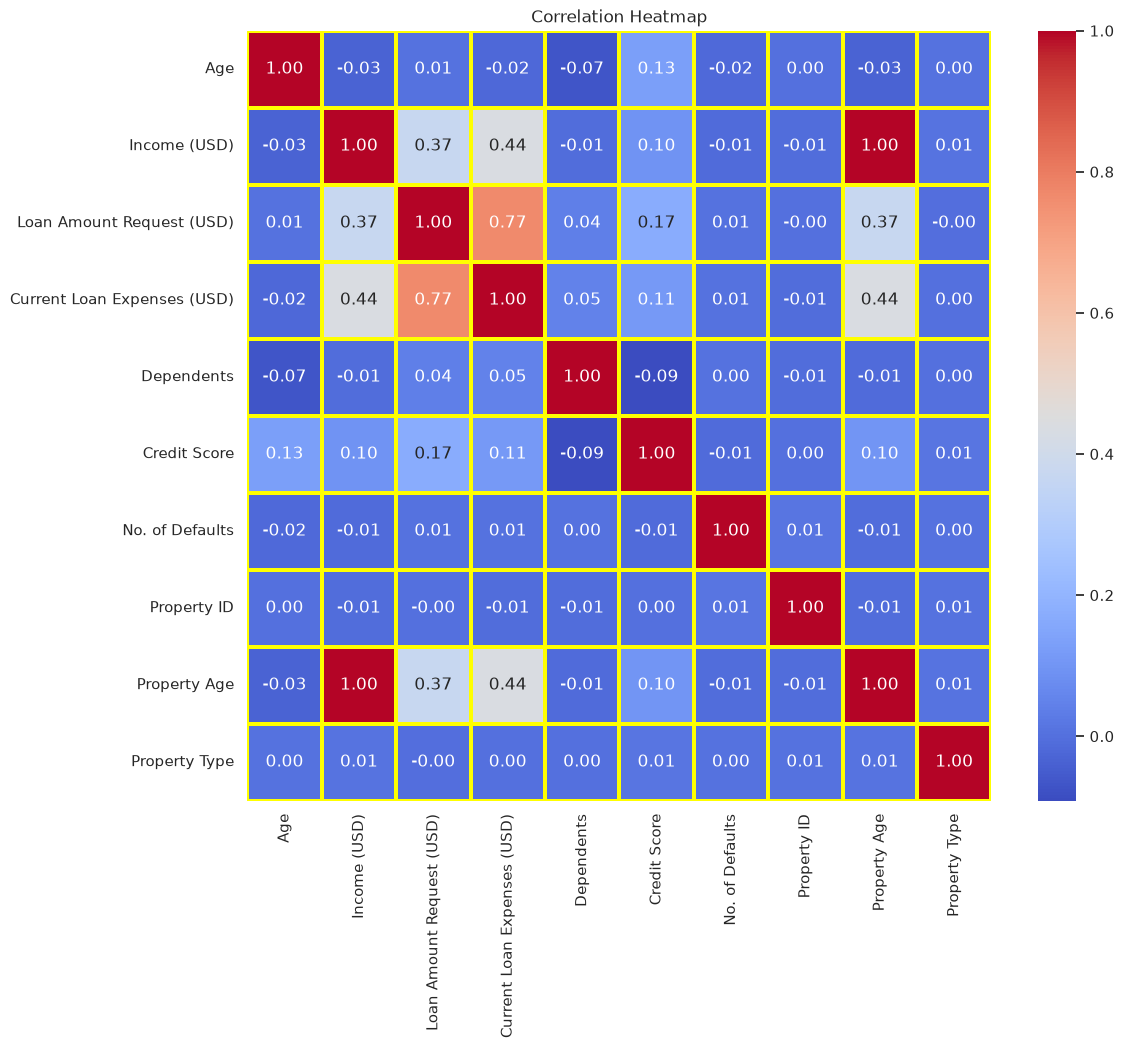



(VIF calculated using a random sample of 5,000 rows for speed calculations)
                      features         VIF
8                 Property Age  571.261245
1                 Income (USD)  570.820382
5                 Credit Score   24.074958
3  Current Loan Expenses (USD)   11.958675
2    Loan Amount Request (USD)    7.619909
0                          Age    7.270789
4                   Dependents    6.318574
9                Property Type    5.543928
7                  Property ID    3.815199
6              No. of Defaults    1.229646




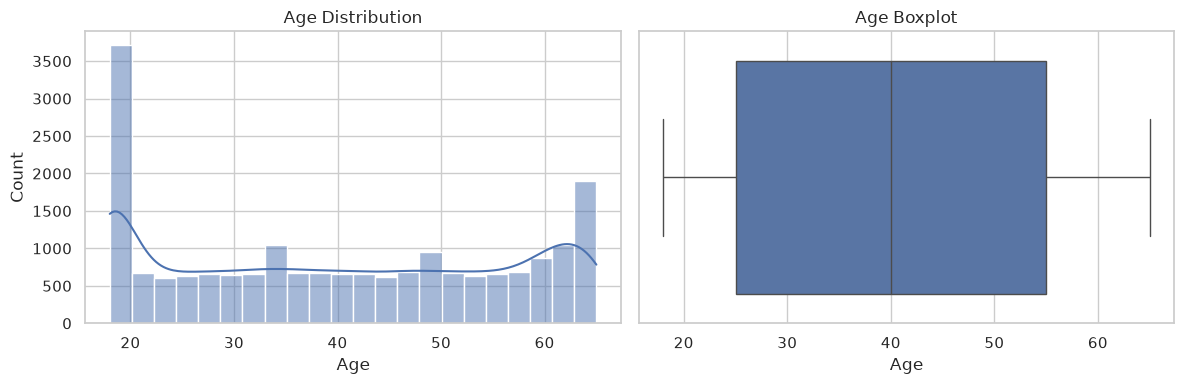

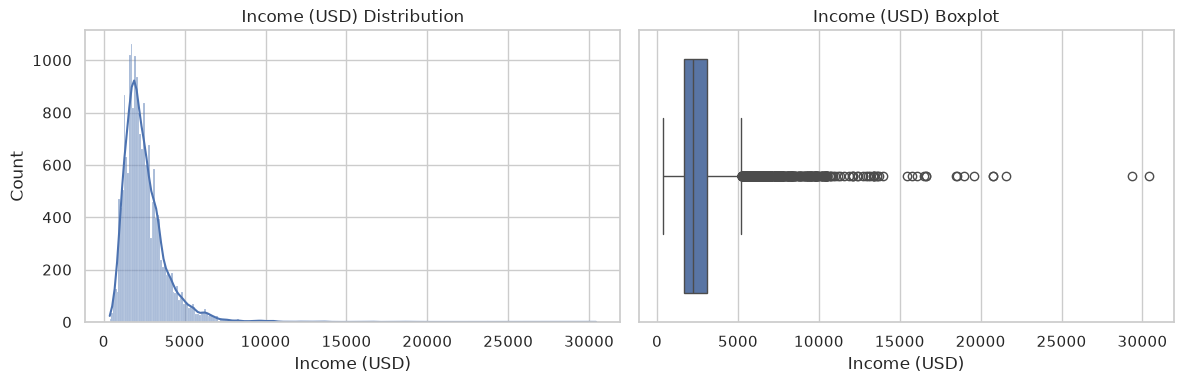

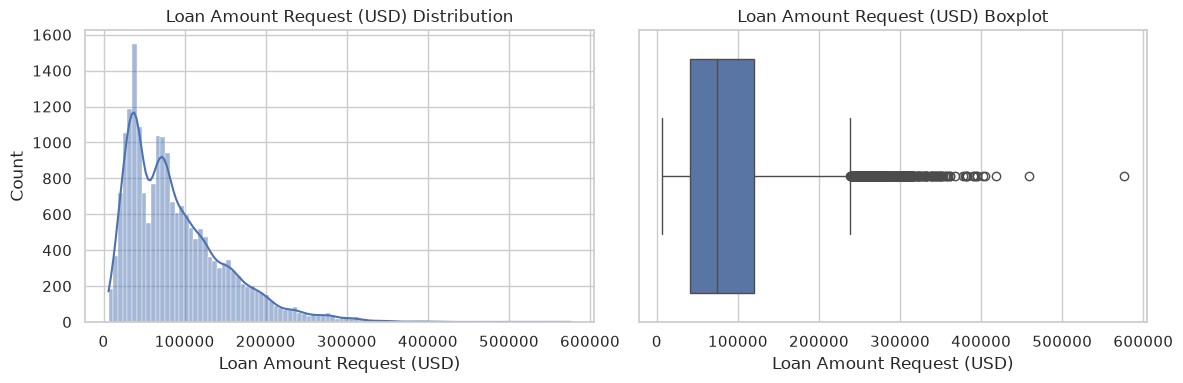

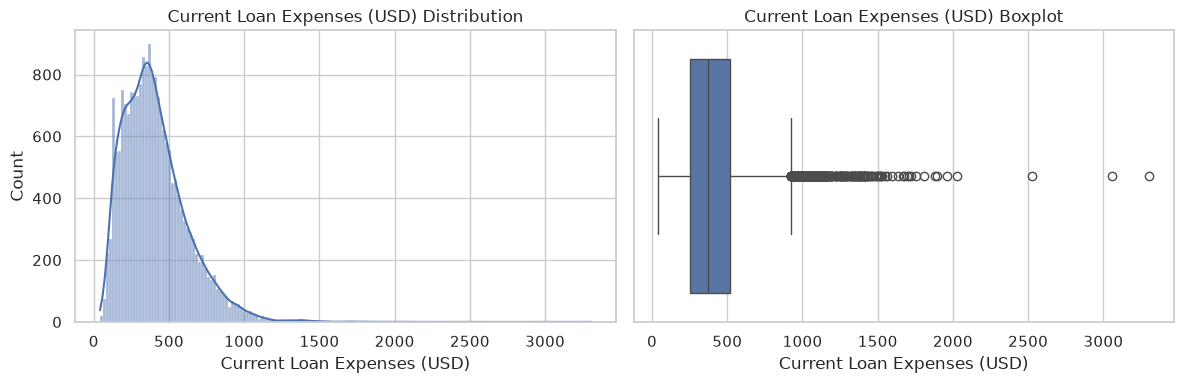

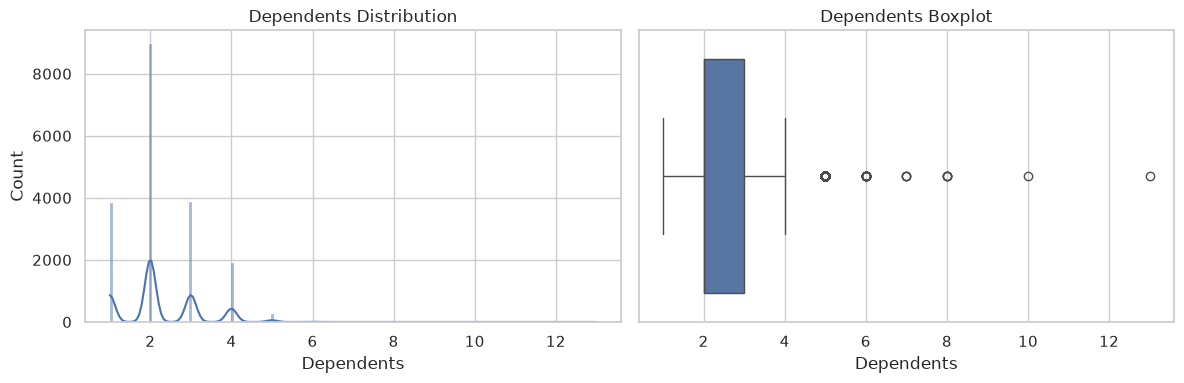

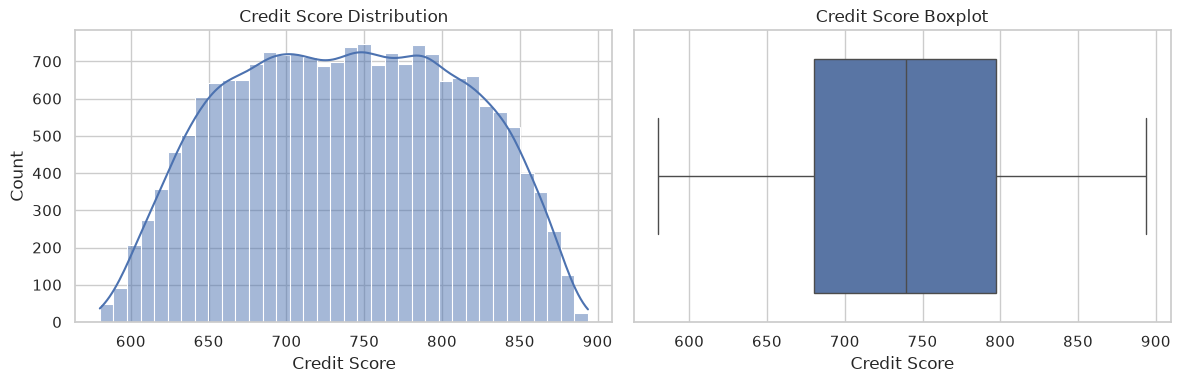

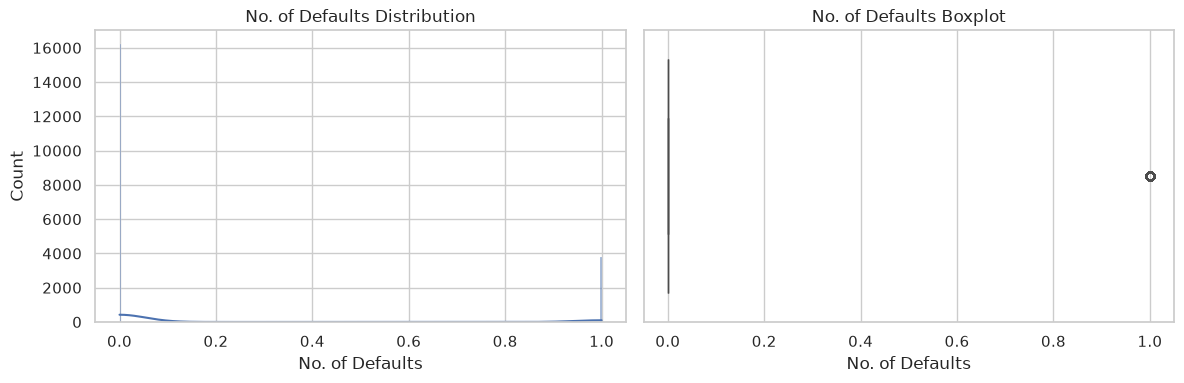

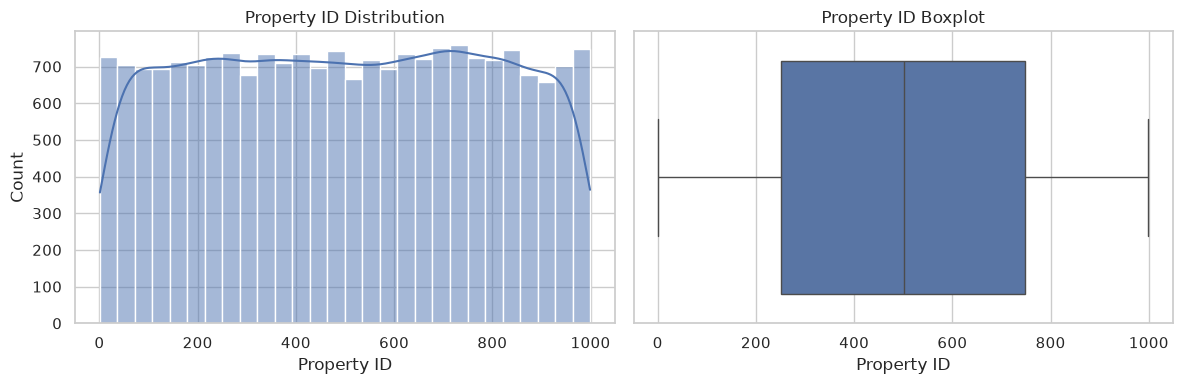

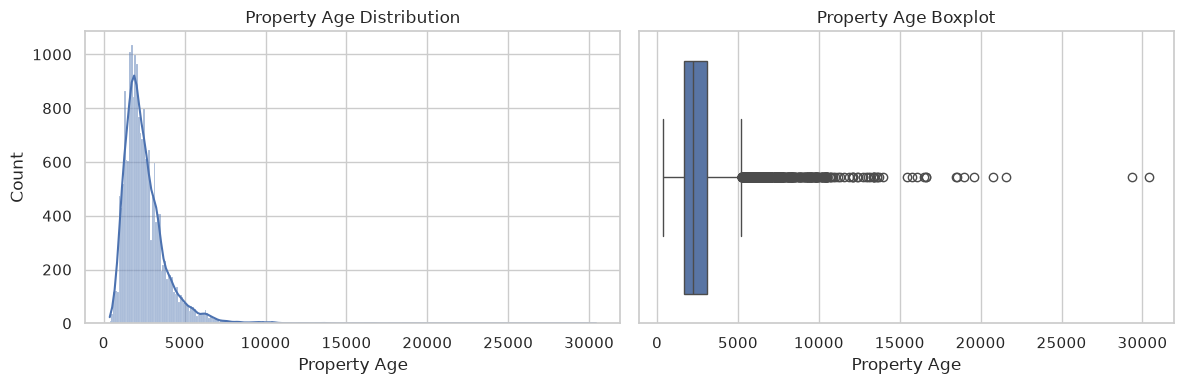

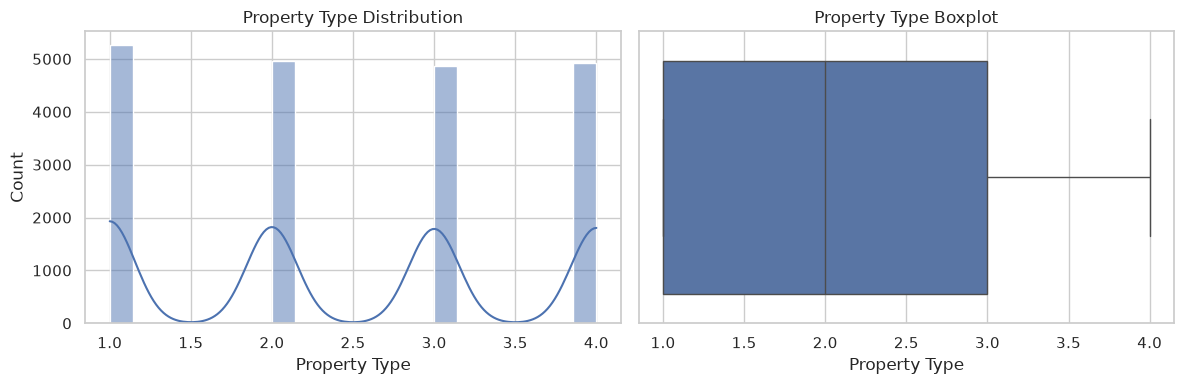

Preprocessing Completed
 Feature Engineering Completed

[PIPELINE COMPLETE]
Final Feature Shape: (20000, 8)


In [10]:
file_path = "test.csv"   # change accordingly
target_column = "Loan Amount Request (USD)"    # IMPORTANT

df = pd.read_csv(
    file_path,
    skipinitialspace=True,
    encoding="utf-8",
    on_bad_lines="skip",
    low_memory=False
)

pipeline_result = tabular_pipeline(file_path, target_column)
X = pipeline_result["X"]
y = pipeline_result["y"]

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

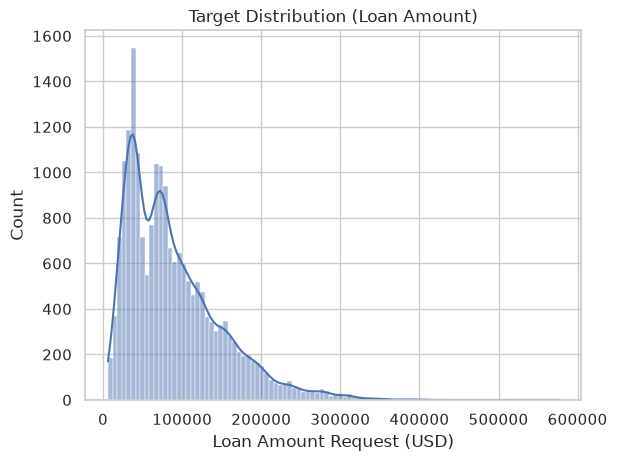

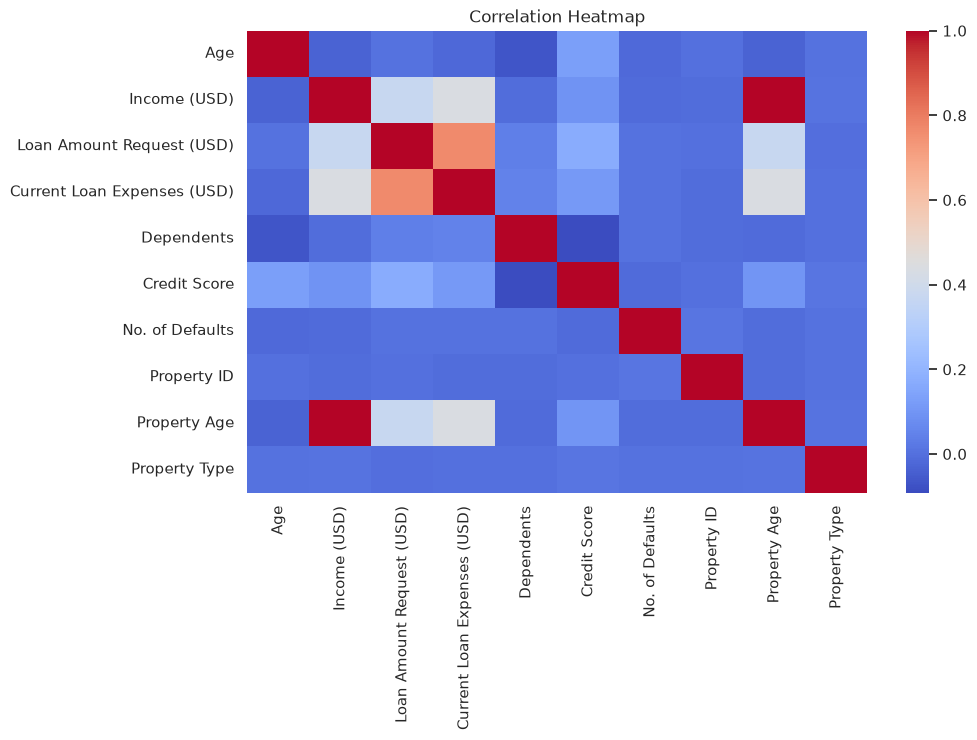

In [12]:
# Target distribution
plt.figure()
sns.histplot(y, kde=True)
plt.title("Target Distribution (Loan Amount)")
plt.show()

# Correlation heatmap
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

In [13]:
def evaluate_model(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)
    return mae, mse, rmse, r2

In [14]:
models = {
    "Linear": LinearRegression(),
    "Ridge": Ridge(),
    "Lasso": Lasso(),
    "ElasticNet": ElasticNet()
}

results = {}
trained_models = {}

for name, model in models.items():
    start = time.time()
    model.fit(X_train, y_train)
    train_time = time.time() - start

    y_pred = model.predict(X_test)

    mae, mse, rmse, r2 = evaluate_model(y_test, y_pred)

    results[name] = {
        "MAE": mae,
        "MSE": mse,
        "RMSE": rmse,
        "R2": r2,
        "Train Time": train_time
    }

    trained_models[name] = model

In [15]:
param_grid = {
    "Ridge": {"alpha": [0.01, 0.1, 1, 10, 100]},
    "Lasso": {"alpha": [0.001, 0.01, 0.1, 1, 10]},
    "ElasticNet": {
        "alpha": [0.01, 0.1, 1, 10],
        "l1_ratio": [0.2, 0.5, 0.8]
    }
}

best_models = {}

for name in ["Ridge", "Lasso", "ElasticNet"]:
    grid = GridSearchCV(
        models[name],
        param_grid[name],
        cv=5,
        scoring="r2",
        n_jobs=-1
    )

    grid.fit(X_train, y_train)

    best_models[name] = grid.best_estimator_

    print(f"{name} Best Params:", grid.best_params_)
    print(f"{name} Best CV R2:", grid.best_score_)

Ridge Best Params: {'alpha': 10}
Ridge Best CV R2: 0.6104374417677773
Lasso Best Params: {'alpha': 0.001}
Lasso Best CV R2: 0.6104362203620559
ElasticNet Best Params: {'alpha': 0.01, 'l1_ratio': 0.8}
ElasticNet Best CV R2: 0.6104376796052572


In [16]:
for name, model in best_models.items():
    y_pred = model.predict(X_test)
    mae, mse, rmse, r2 = evaluate_model(y_test, y_pred)

    results[name + "_Tuned"] = {
        "MAE": mae,
        "MSE": mse,
        "RMSE": rmse,
        "R2": r2
    }

In [17]:
for name, model in best_models.items():
    y_pred = model.predict(X_test)
    mae, mse, rmse, r2 = evaluate_model(y_test, y_pred)

    results[name + "_Tuned"] = {
        "MAE": mae,
        "MSE": mse,
        "RMSE": rmse,
        "R2": r2
    }

In [18]:
results_df = pd.DataFrame(results).T
print(results_df)

                           MAE           MSE          RMSE        R2  \
Linear            27245.298889  1.409237e+09  37539.807924  0.610367   
Ridge             27245.476313  1.409241e+09  37539.853831  0.610366   
Lasso             27245.182194  1.409233e+09  37539.758604  0.610368   
ElasticNet        30824.135925  1.639655e+09  40492.655600  0.546660   
Ridge_Tuned       27247.091228  1.409272e+09  37540.277792  0.610357   
Lasso_Tuned       27245.298778  1.409237e+09  37539.807876  0.610367   
ElasticNet_Tuned  27251.217010  1.409356e+09  37541.395105  0.610334   

                  Train Time  
Linear              0.004560  
Ridge               0.002927  
Lasso               0.023137  
ElasticNet          0.008800  
Ridge_Tuned              NaN  
Lasso_Tuned              NaN  
ElasticNet_Tuned         NaN  


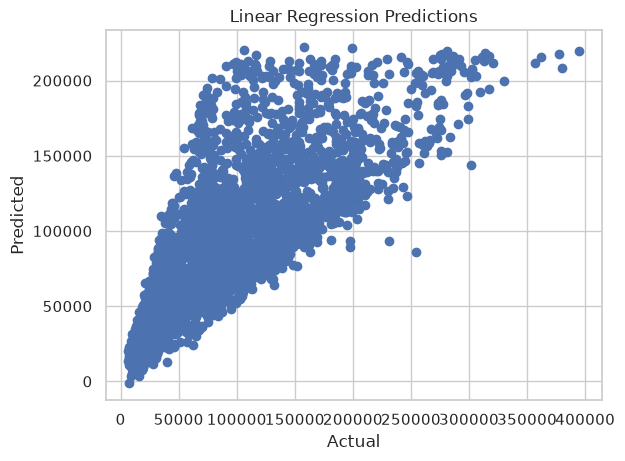

In [19]:
plt.figure()
plt.scatter(y_test, trained_models["Linear"].predict(X_test))
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Linear Regression Predictions")
plt.show()

In [20]:
coef_df = pd.DataFrame({
    "Linear": trained_models["Linear"].coef_,
    "Ridge": best_models["Ridge"].coef_,
    "Lasso": best_models["Lasso"].coef_,
    "ElasticNet": best_models["ElasticNet"].coef_
}, index=X.columns)

print(coef_df)

                                   Linear         Ridge         Lasso  \
Current Loan Expenses (USD)  44894.252949  44859.279865  44894.252500   
interaction_feature            929.842305    929.163265    929.841284   
Age                           1020.730159   1020.360575   1020.729132   
Property ID                    295.692512    295.440407    295.691487   
Dependents                     732.557769    734.040894    732.556654   
Property Type                 -387.498134   -387.072371   -387.497107   
Credit Score                  4828.968314   4828.588905   4828.967425   
Income (USD)                  2490.304206   2505.045931   2490.303420   

                               ElasticNet  
Current Loan Expenses (USD)  44782.572113  
interaction_feature            927.664072  
Age                           1019.537356  
Property ID                    294.878333  
Dependents                     737.272877  
Property Type                 -386.129831  
Credit Score                  4827